# Closed-loop identification

This notebook identifies the closed-loop drivetrain below directly from recorded experiments.

<p align="center">
<img src="docs/experimental_setup.png" alt="Experimental setup" width="600">
</p>

During controller and plant identification, a piecewise-constant load torque disturbs the top motor, so the measured dynamics include the operating conditions of the deployed system.

We first estimate the unknown right controller as a linear PI model, then identify the two-input, three-output plant as a nonlinear LFR model.


<p align="center">
<img src="docs/dual-motor-drivetrain-block-diagram_light.drawio.svg" alt="Closed-loop drivetrain block diagram" width="800">
</p>


## Experimental conditions

We perform three closed-loop experiments. `controller_id` excites the setpoint to identify the unknown right controller; `plant_id` excites both plant inputs to identify the drivetrain; and `validation` repeats the closed-loop experiment without the load disturbance. The table lists the signals applied in each experiment.

$$
\begin{array}{c||c|c|c}
\rule[-0.7em]{0pt}{1.8em} & \texttt{controller\_id} & \texttt{plant\_id} & \texttt{validation} \\
\hline\hline
\rule[-0.7em]{0pt}{1.8em} r_1 & \text{setpoint + multisine} & \text{setpoint} & \text{setpoint}  \\
\hline
\rule[-0.7em]{0pt}{1.8em} r_2 & 0 & \text{orthogonal multisine} & \text{orthogonal multisine}\\
\hline
\rule[-0.7em]{0pt}{1.8em} \tau_{\text{load}} & \text{piecewise-constant} & \text{piecewise-constant} & 0\\
\end{array}
$$


In [1]:
import best_linear_approximation as bla
import freq_statespace as fss
import matplotlib.pyplot as plt
import numpy as np
import jax

from utils import plot_bla_analysis, simulate_closed_loop

SAMPLING_FREQUENCY = 100.0
RIGHT_INPUT_ID = 1
TOP_OUTPUT_ID = 1


## Controller identification

`K_left` is known from the deployment and is set directly. To identify the unknown right controller, we first estimate its closed-loop nonparametric BLA from the recorded reference, control-error, and right-motor signals. We fit and fine-tune a first-order linear (PI) model to this BLA.


Detected 102 excited frequency bins from 9.77e-02 Hz to 9.96 Hz; every bin in that interval is excited (full multisine).
=============== Frequency-domain subspace identification ===============
BLA simulation error: 46.34%.

=========================== BLA optimization ===========================
Starting iterative optimization...
    Iter 1 | loss = 1.2377e+00
    Iter 2 | loss = 1.2377e+00
    Iter 3 | loss = 1.2281e+00
    Iter 4 | loss = 1.2281e+00
    Iter 5 | loss = 1.2281e+00
    Iter 6 | loss = 1.2281e+00
    Iter 7 | loss = 1.2281e+00
    Iter 8 | loss = 1.2281e+00
Optimization completed in 0.02s (8 iterations, 0.93ms/iter).

BLA simulation error: 48.84%.



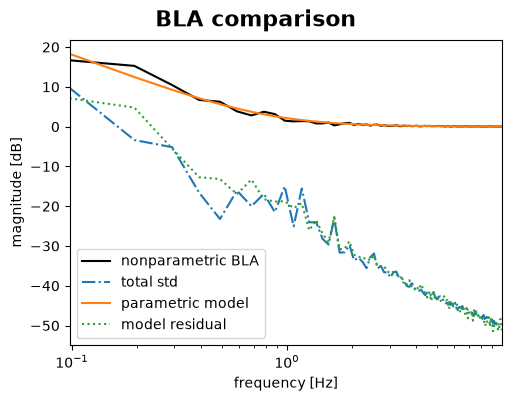

In [2]:
with np.load("data/controller_id.npz") as controller_archive:
    r_1_controller = controller_archive["r_1"]
    u_controller = controller_archive["u"]
    y_controller = controller_archive["y"]

# We know K_left exactly and represent it as a first-order linear state-space model
K_left = fss.ModelBLA(A=1.0, B_u=1.0, C_y=0.05, D_yu=1.025, ts=1.0 / SAMPLING_FREQUENCY)

# Estimate a controller BLA from error input to controller output, using reference as instrumental variable
e_controller = r_1_controller[..., None] - y_controller[:, [TOP_OUTPUT_ID], ...]
K_right_bla = bla.robust.closed_loop(
    r=r_1_controller,
    u=e_controller[..., 1:],
    y=u_controller[:, [RIGHT_INPUT_ID], :, 1:],
    fs=SAMPLING_FREQUENCY,
    show_warnings=False,
)
K_right_data = fss.create_data_object_from_bla(K_right_bla)
K_right = fss.lin.subspace_id(K_right_data, nx=1)
K_right = fss.lin.optimize(K_right, K_right_data)

plot_bla_analysis(K_right_bla, K_right)

## Plant identification

We next estimate the two-input, three-output drivetrain plant under the same closed-loop, load-disturbed conditions. A closed-loop nonparametric BLA provides the frequency-domain target. We first fit and fine-tune a linear state-space model with direct feedthrough fixed to zero, then extend it with a neural-network static nonlinearity to obtain a nonlinear LFR model. The first period is excluded as a transient.


Detected 102 excited frequency bins from 9.77e-02 Hz to 9.96 Hz; every bin in that interval is excited (full multisine).
=============== Frequency-domain subspace identification ===============
BLA simulation error:
    output 1: 184.32%.
    output 2: 206.81%.
    output 3: 181.12%.

================= Stability-enforced BLA optimization ==================
Starting iterative optimization...
    Iter 1 | loss = 1.9304e+01
    Iter 101 | loss = 6.2724e+00
Optimization completed in 0.36s (194 iterations, 1.38ms/iter).

BLA simulation error:
    output 1: 103.18%.
    output 2: 109.92%.
    output 3: 121.29%.



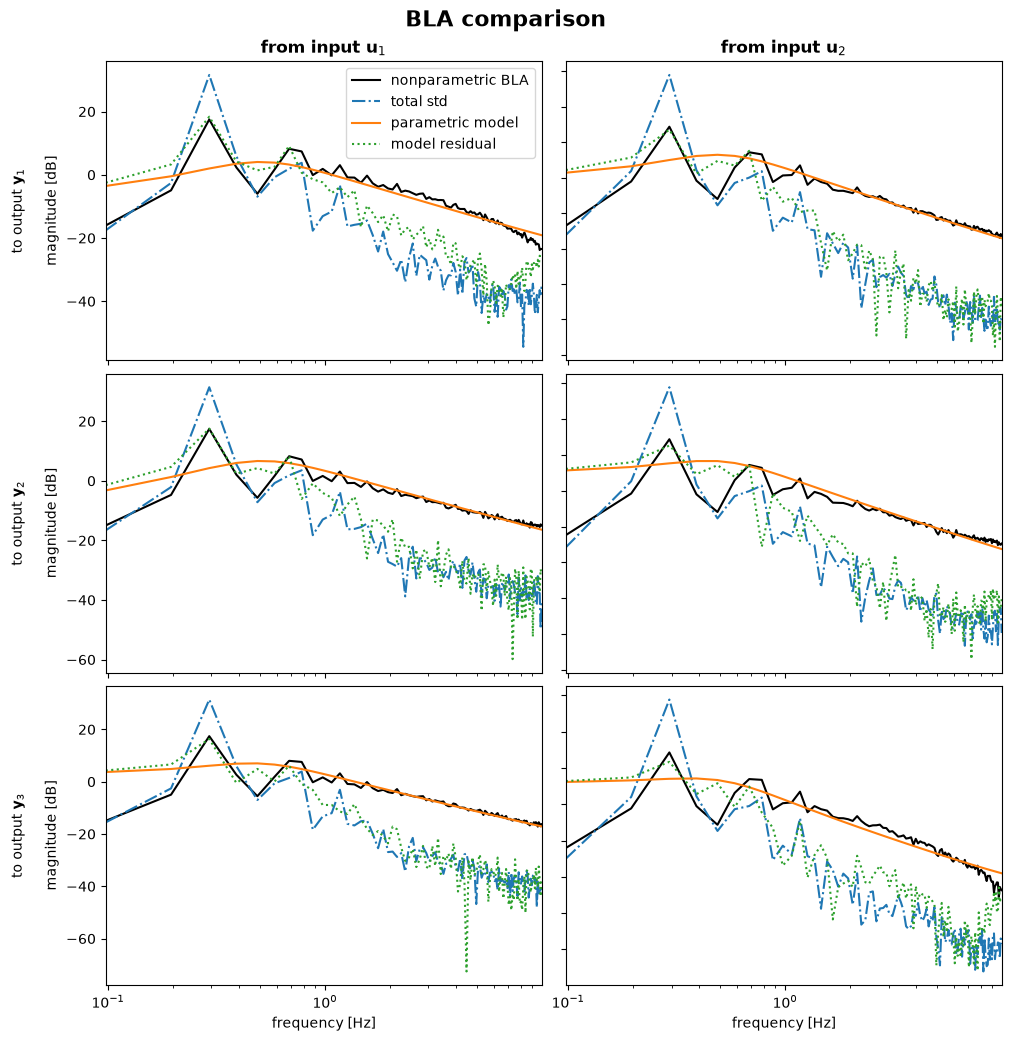

========================= NL-LFR optimization ==========================
Starting iterative optimization...
    BLA loss: 2.6799e+01
    Iter 1 | loss = 2.6811e+01
    Iter 11 | loss = 8.8733e+00
    Iter 21 | loss = 8.6023e+00
    Iter 31 | loss = 8.2737e+00
    Iter 41 | loss = 8.1858e+00
    Iter 51 | loss = 8.1165e+00
    Iter 61 | loss = 8.0997e+00
    Iter 71 | loss = 8.0900e+00
    Iter 81 | loss = 8.0826e+00
    Iter 91 | loss = 8.0803e+00
Optimization completed in 9.84s (100 iterations, 96.23ms/iter).

NL-LFR simulation error:
    output 1: 59.52%.
    output 2: 59.84%.
    output 3: 59.32%.



In [3]:
with np.load("data/plant_id.npz") as plant_archive:
    r_2_plant = plant_archive["r_2"]
    u_plant = plant_archive["u"]
    y_plant = plant_archive["y"]

plant_bla = bla.robust.closed_loop(
    r=r_2_plant,
    u=u_plant[..., 1:],
    y=y_plant[..., 1:],
    fs=SAMPLING_FREQUENCY,
    show_warnings=False,
)
plant_data = fss.create_data_object_from_bla(plant_bla)
plant = fss.lin.subspace_id(plant_data, nx=3, estimate_direct_feedthrough=False)
plant = fss.lin.optimize(
    plant,
    plant_data,
    estimate_direct_feedthrough=False,
    enforce_stability=True,
    print_every=100,
)

plot_bla_analysis(plant_bla, plant)

neural_net = fss.static.NeuralNetwork(
    nw=1,
    nz=3,
    layers=1,
    neurons_per_layer=16,
    activation=jax.nn.relu,
)

plant = fss.nonlin.connect(plant, neural_net)
plant = fss.nonlin.optimize(
    plant,
    plant_data,
    estimate_direct_feedthrough=False,
    print_every=10,
)


## Closed-loop validation

Validation uses a separate, disturbance-free closed-loop measurement. We reconnect the identified `K_left`, right PI controller, and nonlinear-LFR plant according to the deployment block diagram, then compare the resulting complete closed-loop simulation with the measured three-motor response. This tests both the individual models and their full interconnection structure.


In [4]:
with np.load("data/validation.npz") as validation_archive:
    r_1_validation = validation_archive["r_1"]
    r_2_validation = validation_archive["r_2"]
    y_validation = validation_archive["y"]

y_simulation = simulate_closed_loop(
    r_1_validation,
    r_2_validation,
    K_left,
    K_right,
    plant,
)
error = y_validation[..., 1:] - y_simulation[..., 1:]
rmse = np.sqrt(np.mean(error**2, axis=(0, 2, 3)))
output_std = np.std(y_validation[..., 1:], axis=(0, 2, 3))
nrmse = 100.0 * rmse / output_std

print("Closed-loop validation NRMSE:")
for output_id, value in enumerate(nrmse):
    print(f"  output {output_id + 1}: {value:.2f}%")


Closed-loop validation NRMSE:
  output 1: 35.56%
  output 2: 32.99%
  output 3: 35.60%


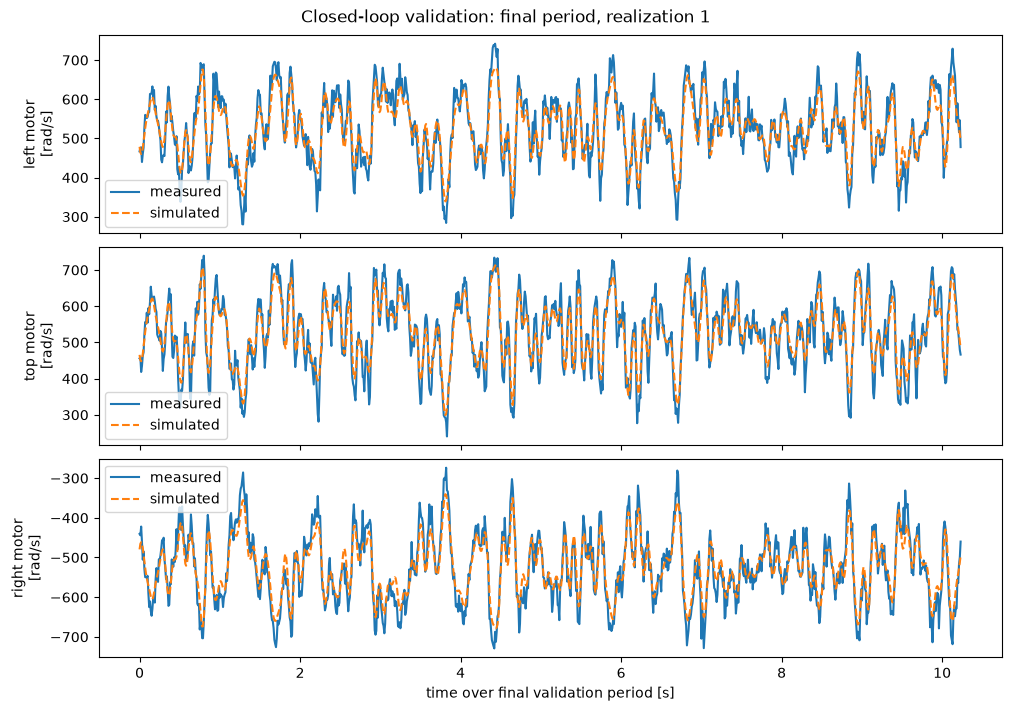

In [5]:
y_measured_last = y_validation[..., -1]
y_simulated_last = y_simulation[..., -1]
time = np.arange(y_measured_last.shape[0]) / SAMPLING_FREQUENCY
output_names = ("left motor", "top motor", "right motor")

figure, axes = plt.subplots(3, 1, figsize=(10, 7), sharex=True, layout="constrained")
for output_id, axis in enumerate(axes):
    axis.plot(time, y_measured_last[:, output_id, 0], label="measured")
    axis.plot(time, y_simulated_last[:, output_id, 0], "--", label="simulated")
    axis.set_ylabel(f"{output_names[output_id]}\n[rad/s]")
    axis.legend()

axes[-1].set_xlabel("time over final validation period [s]")
figure.suptitle("Closed-loop validation: final period, realization 1")
plt.show()
